## EDA esercizio
<img src="https://frenzy86.s3.eu-west-2.amazonaws.com/python/EDA2.jpg" width=800 >


# TIPS

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

path = 'https://frenzy86.s3.eu-west-2.amazonaws.com/fav/tips.csv'

tips = pd.read_csv(path)
tips
# Targert tip

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


A data frame with 244 observations on the following 8 variables.


**total_bill:** a numeric vector, the bill amount (dollars)

**tip:**a numeric vector, the tip amount (dollars)

**sex:** factor with levels Female Male, gender of the payer of the bill

**smoker:** factor with levels No Yes, whether the party included smokers

**day:** factor with levels Friday Saturday Sunday Thursday, day of the week

**time:** factor with levels Day Night, rough time of day

**size:** numeric vector, number of people in party

In [15]:
# sns.set()
# tips = sns.load_dataset("tips")
# tips.head()

In [2]:
tips.describe().T

,count,mean,std,min,25%,50%,75%,max
total_bill,244.0,19.785943,8.902412,3.07,13.3475,17.795,24.1275,50.81
tip,244.0,2.998279,1.383638,1.00,2.0000,2.900,3.5625,10.00
size,244.0,2.569672,0.951100,1.00,2.0000,2.000,3.0000,6.00


In [3]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [4]:
tips.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [5]:
tips['smoker'].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

In [6]:
!pip install missingno -q

In [7]:
tips[tips.duplicated()]

,total_bill,tip,sex,smoker,day,time,size
202,13.0,2.0,Female,Yes,Thur,Lunch,2


In [8]:
tips = tips.drop_duplicates().reset_index(drop=True)
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
238,29.03,5.92,Male,No,Sat,Dinner,3
239,27.18,2.00,Female,Yes,Sat,Dinner,2
240,22.67,2.00,Male,Yes,Sat,Dinner,2
241,17.82,1.75,Male,No,Sat,Dinner,2


## EDA

<Axes: >

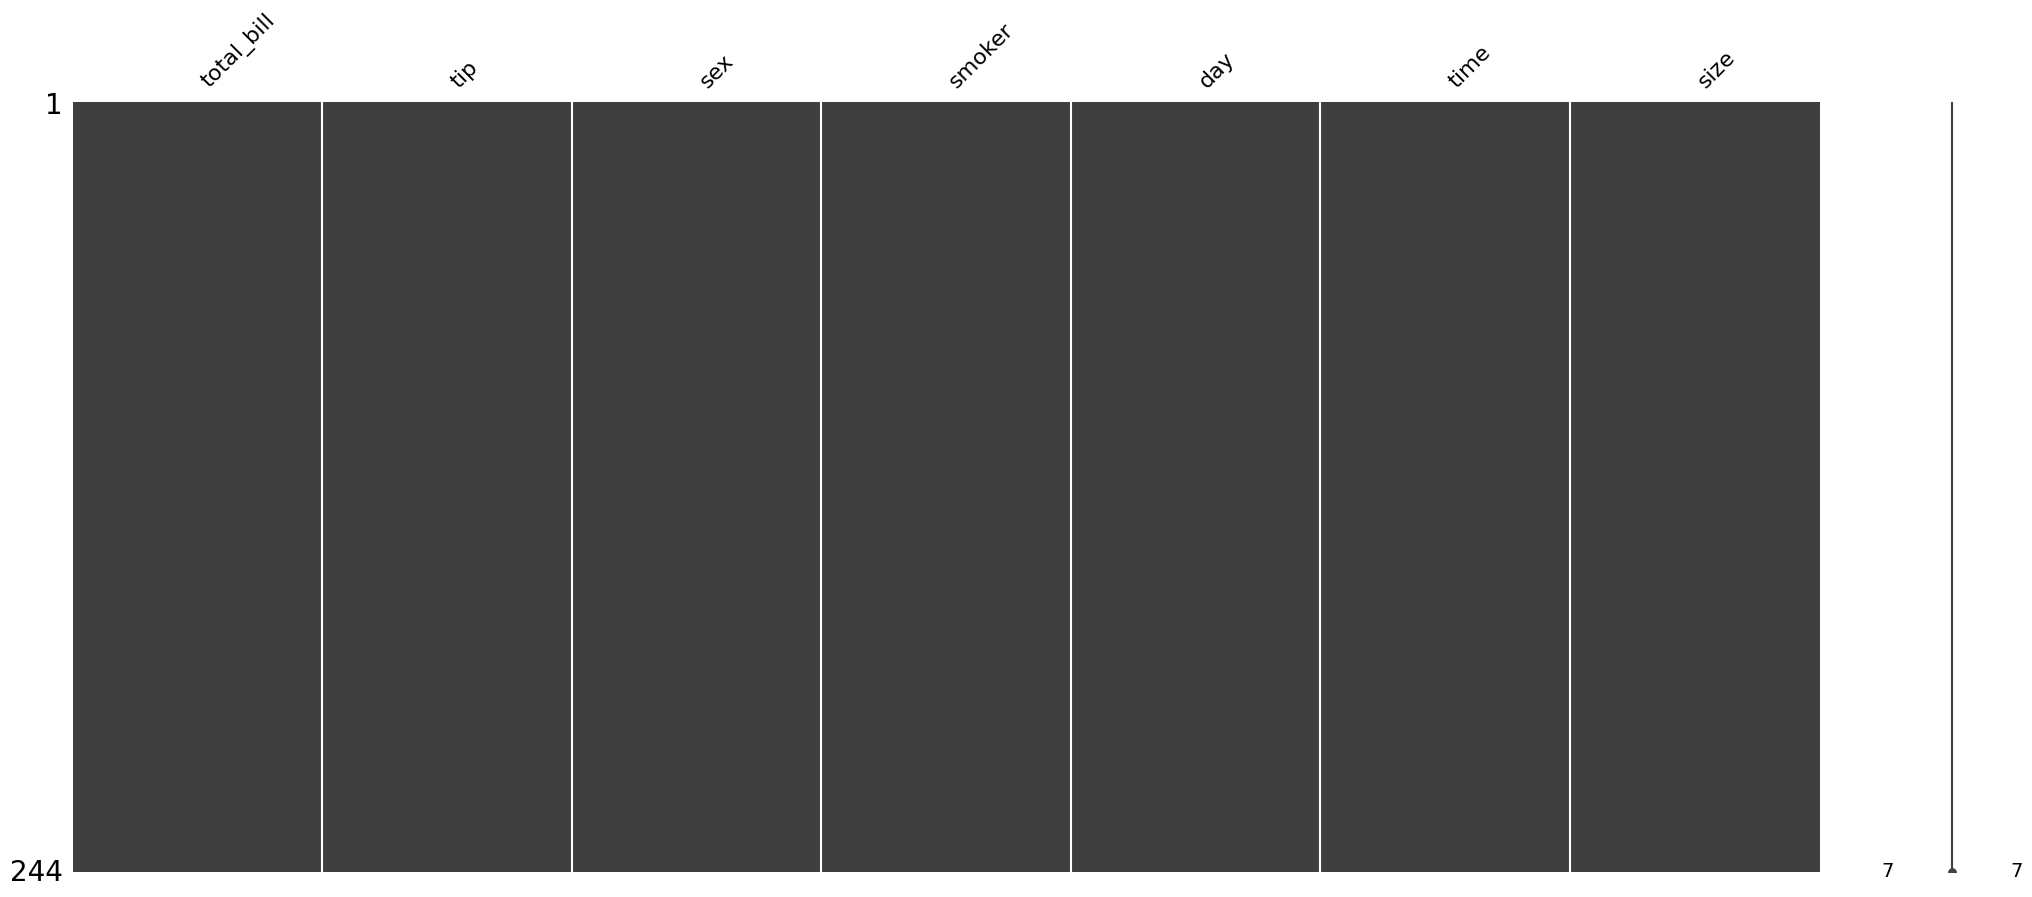

In [22]:
import missingno as msno
msno.matrix(tips)

In [23]:
!pip install jupyter-summarytools -q

from summarytools import dfSummary
dfSummary(tips)

No,Variable,Stats / Values,Freqs / (% of Valid),Graph,Missing
1,total_bill[float64],Mean (sd) : 19.8 (8.9)min < med < max:3.1 < 17.8 < 50.8IQR (CV) : 10.8 (2.2),229 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAArhJREFUeJzt3T2O2kAYgOFvwoIGkGzxI+i4wEopkGg4QMocNkdIQZGaG9AhIQSCrIUxpGKbsPzM2Hg+6336wS5eIY89Hpvz+SxA6L6VfQLAI97KPoFbjDFNEWk4Dj+cz+ePPM8H5Qk2VGNMs9fr/YyiqOMyfrvdro0xv4i1GoINVUQaURR1ptPpRxzHyTMDN5uNnc1mndVq1RARQq2AkEMVEZE4jpPBYPDXYWgz95NBaZhMQQVChQqEChUIFSoQKlQgVKhAqFCBUKECoUIFQoUKhAoVCBUqECpUCH71lKssy+oiEhljXH+ChdcBqWSo+/2+nqbp99FoVKvVak+tZb1g4XVYKhnq4XB4s9a2xuNxMhwO18+OZ+F1eCoZ6kW73XZddC3CwuugMJmCCoQKFQgVKhAqVCBUqFDorN9zp5PodDrV8zwf6FVYqL47naRparMse0+S5LeIuN5iQkUU+Y/qvNOJiMhisejM5/PW8XisFXFy0KXwG/6uO52s12tuuOMTkymoQKhQgVChAqFCBUKFCoQKFQgVKlR64bQPz3eueN8qZ4R6he87V7xvlT9CvcLnnSvetyoGod7g8c4Vj39zxmQKKhAqVCBUqECoUIFQoQKhQgVChQrcRy0Aj1/zR6g54/FrMQg1Zzx+LQahFoTHr/liMgUVCBUqECpU4Bo1MHzN5TpCDQhfc/kaoQaEr7l8jVADxNdc/sdkCirc/Uf12DWaHaNLUNV1BjdD9dk1mh2jX6/K6wzu/aM67xrNjtGvV+V1Bg9Nplx2jWbH6PKUtc7A8+MiNy87mPXjk+f1re12uz/iOG67DL532UGoEBH/69s0Ta2IvE8mkz/9fn/7zNhHLjsIFSLi/7DhMiex1qZFXHY8FOpms7HPHnW321kRkf1+b5fLZeuV47UeO4Tz9uVy7Ef6+gfYWqq6eigVFgAAAABJRU5ErkJggg=="">",0(0.0%)
2,tip[float64],Mean (sd) : 3.0 (1.4)min < med < max:1.0 < 2.9 < 10.0IQR (CV) : 1.6 (2.2),123 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAqdJREFUeJzt3buu2kAUQNEzcEHmEVuIK+hoUkZKQUmTP8jHpk0XJPgB2lQ0CAkZEA4IY0gRUUS54jFjJ3OcvfrBLrYwxvaxuVwuAviu8q93AHjES5EfboxpiEjd4SOOl8tln9f+QK/CQjXGNLrd7ucwDDu2n7HdbmNjzBdiRZHfqPUwDDuj0WgfRdHh2cWbzSaYTCad1WpVFxFC/c8VeugXEYmi6NDr9X5YLm/kujNQi5MpqECoUIFQoQKhQgVChQqEChUIFSoU/j+qiyzLaiISGmNslnP5tUS8DTVJklqaph8Hg0G1Wq0+fWWLy6/l4m2ox+PxJQiC5nA4PPT7/fiZtVx+LR9vQ71qtVq2l2C5/FoinExBBUKFCoQKFQgVKhAqVCBUqECoUIFQoQKhQgVChQqEChUIFSoQKlQgVKhAqFCBUKECoUKFu3f4O8w4Dc/nc81iHfCHm6G6zDhN0zTIsuzD4XD4JiK20/wAEbn/jWo943Q+n3dms1nzdDpVHfYPEJEHH+6zmXEaxzEP1yE3nExBBUKFCoQKFQgVKhAqVCBUqECoUIFQoYL30/xsOQ4BFmEQsFdKGarrEGARBgH7ppShugwBFmEQsI9KGeqVwxBgEQYBe4WTKahAqFCBUKFCqX+juuAdV34h1Dfwjiv/EOobeMeVfwj1Bt5x5Q9OpqACoUIFQoUKhAoVCBUqECpUIFSoQKhQgT/8C8B9Avkj1Jy53iewXq93xpivImL1CI2UNHRCzZnLfQKLxeLddDr9NBgMXnnW63eEWhCb+wTiOG64Pus1Ho97q9Xq1RizfXa9/DpnOVusy2P9zSPBQ6FuNpvg2a3udrtARCRJkmC5XDb/5nqt276utbXf761/dmRZVkuS5H273f5eqVTSZ7ftuv7ekeAnFwpR0ITCRagAAAAASUVORK5CYII="">",0(0.0%)
3,sex[object],1. Male2. Female,157 (64.3%)87 (35.7%),"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAAAuCAYAAAA/ZmtKAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAATlJREFUeJzt28Fpw0AURdE3QZhko0EIVIyKSLEpQt0IoVnExpvJwpAO/MbzfU8F3/hibKOXaq0CHJKkL0mX1ofg373Wem19xDMM8zx/j+M4tT4ED6WUI6X0EzG4YRzHaV3Xa8751vqYd3ee5+e2bdO+7xdJ8WKTpJzzbVmW39bHQNLja01IH60PwPsgNtgQG2yIDTbEBhtigw2xwYbYYENssCE22BAbbIgNNsQGG2KDDbHBZpAeD+21PgTx34ehlHJs2zYp8EN7PSmlHJLure94BgYvryfs4CUx5YNL9E+2sJ8SPQo95Ys8i+tR2Clf9Flcj6JP+fiF/UL4Uxc2xAYbYoMNscGG2GBDbLAhNtgQG2yIDTbEBhtigw2xwYbYYENssCE22ISd8kV8Tb0LPeWLPIvrEYMX2PwBCltq38NzG/wAAAAASUVORK5CYII="">",0(0.0%)
4,smoker[object],1. No2. Yes,151 (61.9%)93 (38.1%),"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAAAuCAYAAAA/ZmtKAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAATRJREFUeJzt20FqwzAURdGvYkIzkTAGLyaL6GK7CO3GGGvQhEzUQffwJPruWcFPuBgS/FLvPQCFFBH3iLiNPsTYu/f+HH2EwrJt21fOeR19iKvW2plS+nYIbsk5r4/H41lKeY0+xs11XZ+11vU4jltE/P/YIiJKKa99339GH2PqPvoAlY/RB8AHsUGG2CBDbJAhNsgQG2SIDTLEBhligwyxQYbYIENskCE2yBAbZIgNMkvE30t8ow9x5Pa9L621s9a6htFLfDNprZ0R8R59hwKDl/FsBi+JKR9U3J5sNk+RGVlN+ZxmczOymfK5zeZm5Dbl4xf3QPypCxligwyxQYbYIENskCE2yBAbZIgNMsQGGWKDDLFBhtggQ2yQITbIEBtkbKZ8Dp9xdlZTPqf

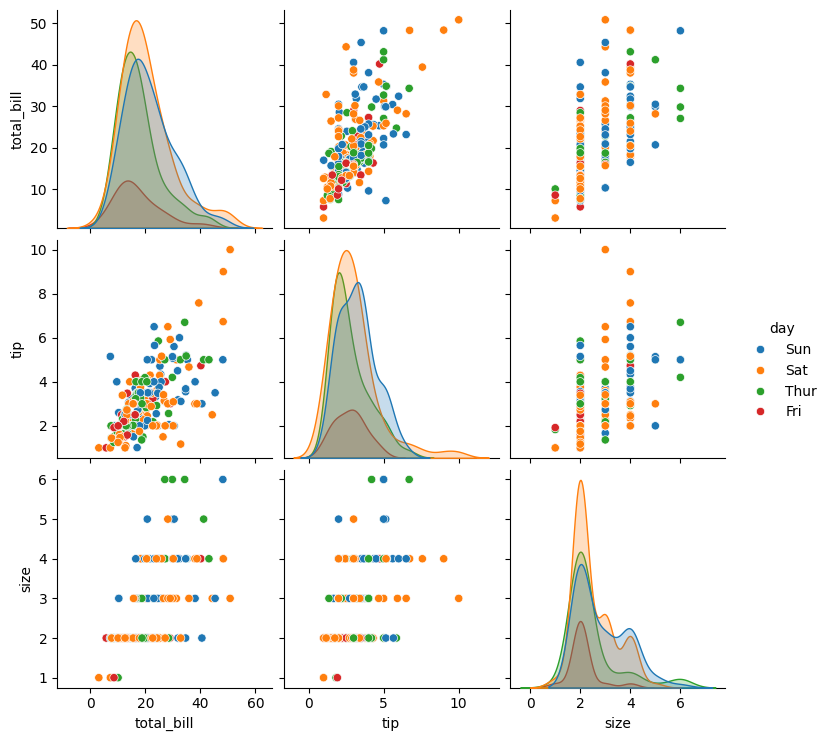

In [25]:
sns.pairplot(tips,hue='day')

In [9]:
corr = tips.corr(numeric_only=True)
corr

,total_bill,tip,size
total_bill,1.000000,0.674998,0.597589
tip,0.674998,1.000000,0.488400
size,0.597589,0.488400,1.000000


<Axes: >

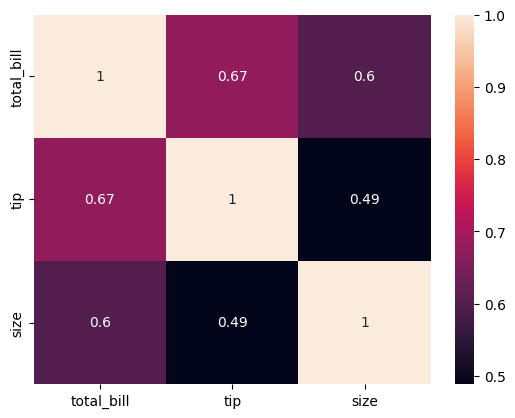

In [10]:
sns.heatmap(corr, annot=True)

In [12]:
#one hot encoding
df = tips.copy()
#'sex', 'smoker', 'day', 'time'
df_dumm = pd.get_dummies(df,columns =['sex', 'smoker', 'day', 'time'],drop_first=True,dtype=int)
df_dumm


,total_bill,tip,size,sex_Male,smoker_Yes,day_Sat,day_Sun,day_Thur,time_Lunch
0,16.99,1.01,2,0,0,0,1,0,0
1,10.34,1.66,3,1,0,0,1,0,0
2,21.01,3.50,3,1,0,0,1,0,0
3,23.68,3.31,2,1,0,0,1,0,0
4,24.59,3.61,4,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...
238,29.03,5.92,3,1,0,1,0,0,0
239,27.18,2.00,2,0,1,1,0,0,0
240,22.67,2.00,2,1,1,1,0,0,0
241,17.82,1.75,2,1,0,1,0,0,0


In [72]:
TARGET = 'tip'
#X_ = df_dumm.drop(columns=[TARGET,'smoker_Yes','sex_Male','size']) # x Modello linear regression
X_ = df_dumm.drop(columns=[TARGET]) #tutte le features x Decision Tree
y = df_dumm[TARGET]

In [73]:
## NORMALIZZIAMO
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()

X = mms.fit_transform(X_)
X

array([[0.29157939, 0.2       , 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.1522832 , 0.4       , 1.        , ..., 1.        , 0.        ,
        0.        ],
       [0.3757855 , 0.4       , 1.        , ..., 1.        , 0.        ,
        0.        ],
       ...,
       [0.41055718, 0.2       , 1.        , ..., 0.        , 0.        ,
        0.        ],
       [0.30896523, 0.2       , 1.        , ..., 0.        , 0.        ,
        0.        ],
       [0.32907415, 0.2       , 0.        , ..., 0.        , 1.        ,
        0.        ]], shape=(243, 8))

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25,
                                                    random_state=667,
                                                    )

In [75]:
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()
model1.fit(X_train,y_train)


LinearRegression()

In [76]:
y_pred = model1.predict(X_test)
y_pred

array([3.20407662, 2.95318463, 3.16074527, 3.97393303, 3.69782545,
       2.08649501, 2.29405565, 2.86567866, 3.85722617, 2.99128967,
       2.30984348, 2.46475064, 3.08263812, 2.23512643, 2.70243041,
       3.15246352, 4.28039633, 2.79331806, 2.31001789, 2.41878246,
       2.93414237, 4.32452819, 5.41954141, 3.12630424, 2.83032817,
       2.90417069, 4.00861214, 2.86114576, 3.56659882, 2.67709236,
       1.84691249, 3.29861813, 6.4702901 , 2.22170448, 3.29501373,
       2.3362986 , 3.06936294, 2.78248964, 2.30750754, 4.33444716,
       2.60523166, 2.93299142, 2.50759572, 2.97465152, 1.87711336,
       1.66574427, 2.15210907, 3.63656882, 1.77412019, 2.04254226,
       2.97291225, 2.0123525 , 2.21685276, 2.11124995, 2.39951652,
       4.12809212, 2.48093656, 4.34375593, 3.69118949, 2.21650252,
       4.08167145])

In [77]:
## STEP5 VERIFICA METRICHE (for Regression)
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error,mean_squared_error

r2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)

print(f'R2 score {r2}')
print(f'MSE score {mse}')
print(f'MAE score {mae}')
print(f'RMSE score {rmse}')

R2 score 0.32788312944546905
MSE score 0.9326257208954188
MAE score 0.7323771107306821
RMSE score 0.9657254894096038


In [78]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

model2 = make_pipeline(PolynomialFeatures(degree=2),
                       LinearRegression(),
                       )
model2.fit(X_train,y_train)


Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                ('linearregression', LinearRegression())])

In [79]:
y_pred = model2.predict(X_test)
y_pred

array([3.09357113, 3.03973044, 3.2890171 , 3.31915632, 3.44695183,
       1.70839873, 2.13469677, 2.97441667, 3.67169495, 3.09505576,
       2.99450509, 2.46885407, 2.93057036, 2.2664098 , 2.36022727,
       3.09497904, 5.41156084, 2.9363586 , 2.31062282, 2.3927866 ,
       3.01705999, 3.80069665, 3.83562125, 2.93595429, 2.4248936 ,
       2.85181557, 3.81133363, 3.06000218, 3.49061729, 2.76140935,
       2.4224524 , 3.61460502, 5.99128979, 1.96586683, 3.42627461,
       2.59164082, 3.17938055, 3.15361375, 2.4097177 , 3.66746349,
       2.25616205, 2.33969077, 2.51804656, 2.88215779, 1.73138418,
       1.46734896, 1.8676565 , 3.54049387, 1.54558835, 4.63369467,
       3.55684063, 2.23718093, 1.92414966, 1.75903198, 2.39082977,
       4.50347942, 2.48741791, 4.12802432, 3.57089639, 2.21265925,
       3.94692905])

In [80]:
## STEP5 VERIFICA METRICHE (for Regression)
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error,mean_squared_error

r2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)

print(f'R2 score {r2}')
print(f'MSE score {mse}')
print(f'MAE score {mae}')
print(f'RMSE score {rmse}')

R2 score 0.21560367299003935
MSE score 1.0884240851473026
MAE score 0.781973274180509
RMSE score 1.0432756515644859


In [81]:
from sklearn.tree import DecisionTreeRegressor

model3 = DecisionTreeRegressor(max_depth=3)
model3.fit(X_train,y_train)


DecisionTreeRegressor(max_depth=3)

In [82]:
y_pred = model3.predict(X_test)
y_pred

array([2.974     , 2.974     , 3.48540541, 3.48540541, 3.48540541,
       1.81880952, 1.81880952, 2.974     , 4.36714286, 3.48540541,
       2.47576923, 2.47576923, 2.974     , 1.81880952, 2.974     ,
       3.48540541, 3.48540541, 2.47576923, 2.47576923, 2.47576923,
       2.974     , 4.36714286, 4.36714286, 3.48540541, 2.47576923,
       2.47576923, 4.36714286, 2.974     , 3.48540541, 2.974     ,
       1.81880952, 3.48540541, 6.73      , 1.81880952, 3.48540541,
       2.47576923, 3.48540541, 2.974     , 2.40090909, 4.36714286,
       2.47576923, 2.974     , 2.47576923, 2.974     , 1.81880952,
       1.81880952, 1.81880952, 4.36714286, 1.81880952, 1.81880952,
       2.974     , 2.40090909, 1.81880952, 1.81880952, 2.47576923,
       3.48540541, 2.47576923, 4.36714286, 4.36714286, 2.40090909,
       3.48540541])

In [83]:
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error,mean_squared_error

r2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)

print(f'R2 score {r2}')
print(f'MSE score {mse}')
print(f'MAE score {mae}')
print(f'RMSE score {rmse}')

R2 score 0.3504327948078171
MSE score 0.9013359276528253
MAE score 0.7495553650307749
RMSE score 0.9493871326560231


In [84]:
from sklearn.model_selection import cross_val_score

score_cross = cross_val_score(model3,X,y,cv=5,scoring='r2')
score_cross.mean()

np.float64(0.4347059356305468)

In [85]:
model3.feature_importances_

array([0.93303531, 0.05407525, 0.        , 0.        , 0.        ,
       0.01288944, 0.        , 0.        ])

In [86]:
from sklearn.model_selection import cross_val_score

#total_bill','day', 'time'
score_cross = cross_val_score(model1,X,y,cv=5,scoring='r2')
score_cross.mean()

np.float64(0.41714348424886677)

In [87]:

## features #total_bill','day', 'time'
## targert= tip
## drop duplicates
## OHE yes
## Normalizz == yes
## model linear regression
## R2 cross 0.43